In [1]:
from Equipments import BNC575
from Equipments import Weeder
from Equipments import SR400
from Equipments import MCBOX
from Equipments import Andor
import numpy as np
import matplotlib.pyplot as plt
import pyvisa
import time
from scipy.signal import find_peaks

ModuleNotFoundError: No module named 'pyvisa'

In [ ]:
vset = np.array([0.1,-0.2,0.4])

vx_list = np.linspace(-10,10,21) + vset[0]
vy_list = np.linspace(-10,10,21) + vset[1]
vz_list = np.linspace(-10,10,21) + vset[2]

v_list = np.vstack((vx_list,vy_list,vz_list))

print(v_list)

[[ -9.9  -8.9  -7.9  -6.9  -5.9  -4.9  -3.9  -2.9  -1.9  -0.9   0.1   1.1
    2.1   3.1   4.1   5.1   6.1   7.1   8.1   9.1  10.1]
 [-10.2  -9.2  -8.2  -7.2  -6.2  -5.2  -4.2  -3.2  -2.2  -1.2  -0.2   0.8
    1.8   2.8   3.8   4.8   5.8   6.8   7.8   8.8   9.8]
 [ -9.6  -8.6  -7.6  -6.6  -5.6  -4.6  -3.6  -2.6  -1.6  -0.6   0.4   1.4
    2.4   3.4   4.4   5.4   6.4   7.4   8.4   9.4  10.4]]


In [ ]:
stride = 1
half_width = 4


# scan list gneration
s_list = np.arange(2* half_width/stride)


i = 1

print('Now checking axis {}'.format(i))
for s in s_list:
    print(f"now checking step: {s}", end = "\r", flush = True)
    for v_s in v_list[i]:
        if v_s < 10.0 and v_s > -10.0:
            print(v_s)
        else:
            continue

Now checking axis 1
-9.2checking step: 0.0
-8.2
-7.2
-6.2
-5.2
-4.2
-3.2
-2.2
-1.2
-0.2
0.8
1.8
2.8
3.8
4.8
5.8
6.8
7.8
8.8
9.8
-9.2checking step: 1.0
-8.2
-7.2
-6.2
-5.2
-4.2
-3.2
-2.2
-1.2
-0.2
0.8
1.8
2.8
3.8
4.8
5.8
6.8
7.8
8.8
9.8
-9.2checking step: 2.0
-8.2
-7.2
-6.2
-5.2
-4.2
-3.2
-2.2
-1.2
-0.2
0.8
1.8
2.8
3.8
4.8
5.8
6.8
7.8
8.8
9.8
-9.2checking step: 3.0
-8.2
-7.2
-6.2
-5.2
-4.2
-3.2
-2.2
-1.2
-0.2
0.8
1.8
2.8
3.8
4.8
5.8
6.8
7.8
8.8
9.8
-9.2checking step: 4.0
-8.2
-7.2
-6.2
-5.2
-4.2
-3.2
-2.2
-1.2
-0.2
0.8
1.8
2.8
3.8
4.8
5.8
6.8
7.8
8.8
9.8
-9.2checking step: 5.0
-8.2
-7.2
-6.2
-5.2
-4.2
-3.2
-2.2
-1.2
-0.2
0.8
1.8
2.8
3.8
4.8
5.8
6.8
7.8
8.8
9.8
-9.2checking step: 6.0
-8.2
-7.2
-6.2
-5.2
-4.2
-3.2
-2.2
-1.2
-0.2
0.8
1.8
2.8
3.8
4.8
5.8
6.8
7.8
8.8
9.8
-9.2checking step: 7.0
-8.2
-7.2
-6.2
-5.2
-4.2
-3.2
-2.2
-1.2
-0.2
0.8
1.8
2.8
3.8
4.8
5.8
6.8
7.8
8.8
9.8


In [7]:
from DataProcessing.Fitting import *
from DataProcessing import Readout
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'Times New Roman'
rcParams['mathtext.fontset'] = 'stix'
rcParams['axes.unicode_minus'] = False
rcParams.update({
	'font.size': 14,
	'axes.titlesize': 14,
	'axes.labelsize': 14,
	'xtick.labelsize': 14,
	'ytick.labelsize': 14,
	'legend.fontsize': 14,
	'figure.titlesize': 14,
	'legend.frameon': False,
})

In [8]:
root_dir = "X:/migratedData/Rydberg_QIS/data"
x1,y1,z1,notes1 = Readout.read_saved_csv_by_id(root_dir=root_dir, date="2025/12/16", plot_id=9)

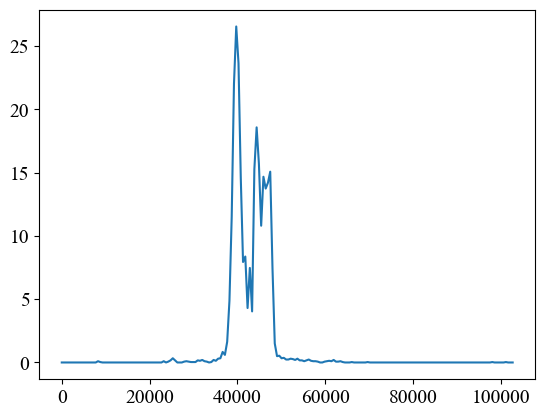

In [9]:
plt.plot(x1,z1)

Data Analysis:
Data points: 200
X range: [0.00, 102684.00]
Z range: [0.00, 26.53]
Z mean: 1.3685, Z std: 4.3595

Fitting 4 peaks:
Selected 4 features at x positions: [39732. 39732. 44376. 45408.]
Estimated amplitudes: [26.53333333 26.53333333 18.56666667 10.8       ]

Initial guess:
Peak 1: A=26.5333, Center=39732.0000, Width=1290.0000
Peak 2: A=26.5333, Center=39732.0000, Width=1290.0000
Peak 3: A=18.5667, Center=44376.0000, Width=2322.0000
Peak 4: A=10.8000, Center=45408.0000, Width=2580.0000
Baseline: 0.0000

Trying multiple fitting strategies:
Strategy 1 (curve_fit with bounds): R² = 0.976574
Strategy 2 (differential evolution): R² = 0.936475

FITTED PARAMETERS (4 peaks):
Peak 1: A=16.9350±3.3993, Center=40244.7055±155.4285, Width=718.0274±122.3163
Peak 2: A=18.8462±4.6919, Center=39434.5728±64.8722, Width=550.4555±83.0004
Peak 3: A=16.6396±0.6460, Center=44423.6659±34.6091, Width=792.1512±60.0026
Peak 4: A=14.4615±0.5848, Center=46854.7893±45.4112, Width=977.2206±72.3836
Baseline 

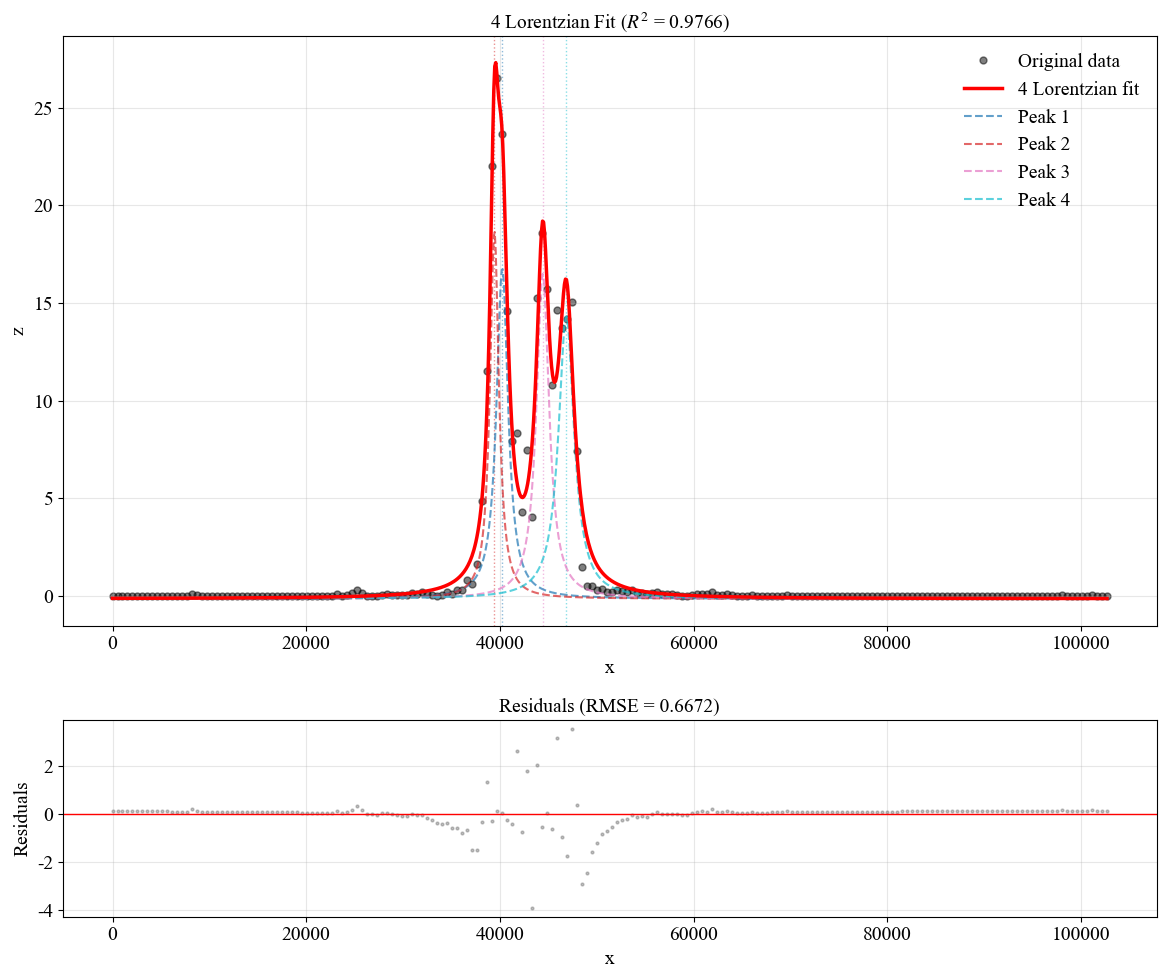

In [11]:
result = fit_and_plot_1d_lorentzian(x1,z1,4)